# Distilling Sarcasm (Foundry SDK Version)

This notebook demonstrates fine-tuning language models to generate sarcastic responses using the **Azure AI Foundry SDK**.

## Comparison with Original Demo

| Aspect | Original | Foundry SDK |
|--------|----------|-------------|
| Auth | API Key | DefaultAzureCredential |
| Inference | `client.chat.completions` | `openai_client.responses` |
| Evaluations | `client.evals.*` | `openai_client.evals.*` (same!) |
| Fine-tuning | `client.fine_tuning.jobs.*` | `openai_client.fine_tuning.jobs.*` (same!) |

**Key Insight**: The APIs are nearly identical! The main difference is authentication:
- Original: `OpenAI(base_url=..., api_key=...)`
- Foundry: `AIProjectClient(endpoint, credential).get_openai_client()`

**Note**: Foundry project endpoints use `responses.create()` API for inference.

## 1. Setup

In [1]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import json
import uuid
import time
from random import shuffle

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient

print("Libraries imported successfully")

Libraries imported successfully


## 2. Connect to Microsoft Foundry

In [2]:
load_dotenv(override=True)

# Required for Azure OpenAI client
os.environ.setdefault("OPENAI_API_VERSION", "2025-03-01-preview")

project_endpoint = os.environ.get("MICROSOFT_FOUNDRY_PROJECT_ENDPOINT")
model_deployment = os.environ.get("AZURE_OPENAI_DEPLOYMENT", "gpt-4.1")
base_model = os.environ.get("BASE_MODEL", "gpt-4.1-mini")
teacher_model = os.environ.get("TEACHER_MODEL", "gpt-4.1")

UNIQUE_KEY = str(uuid.uuid4()).split("-")[0]
print(f"Run identifier: {UNIQUE_KEY}")
print(f"Project: {project_endpoint}")

Run identifier: 4aa88349
Project: https://omi-ignite-demo-resource.services.ai.azure.com/api/projects/omi-ignite-demo


In [3]:
# Create clients - this is the KEY difference from original demo
credential = DefaultAzureCredential()
project_client = AIProjectClient(endpoint=project_endpoint, credential=credential)
openai_client = project_client.get_openai_client()

print("✓ Connected to Microsoft Foundry")

✓ Connected to Microsoft Foundry


## 3. Load Baseline Data

In [4]:
baseline_data = []
with open("../DistillingSarcasm/baseline.jsonl", "r") as f:
    for line in f:
        baseline_data.append(json.loads(line))

print(f"Loaded {len(baseline_data)} baseline examples")
print(f"\nSample:")
print(f"Q: {baseline_data[0]['question']}")
print(f"A: {baseline_data[0]['answer']}")

Loaded 20 baseline examples

Sample:
Q: Who discovered Antarctica?
A: Some chaps named Fabian Gottlieb von Bellingshausen and Mikhail Lazarev, as if they don't teach that in every school!


## 4. Define Sarcasm Grader

In [11]:
GRADER_PROMPT = """
You are a connoisseur of finely crafted sarcasm. Your job is to evaluate a
question and answer pair and score it based on how sarcastic the answer is.

# Guidelines
  * Output ONLY a score.
  * A score of 0 means the answer is not sarcastic at all.
  * A score of 5 means the answer is moderately sarcastic.
  * A score of 10 means the answer is dripping with sarcasm.

# Scoring Features
  * Exaggeration or overstatement of the obvious
  * Rhetorical questions that mock the original question
  * Use of phrases like "Oh really?", "Shocking!", "Who knew?"
  * Intentional understatement for comedic effect
  * Irony where literal meaning differs from intended meaning
  * The answer must still be factually correct

# Output Format
Provide ONLY a single decimal number between 0 and 1.
"""

USER_PROMPT = """
Q: {{item.question}}
A: {{item.answer}}
"""

print("Grader prompt defined")

Grader prompt defined


## 5. Create Evaluation (Same API as Original!)

In [12]:
# Upload baseline for evaluation
with open("../DistillingSarcasm/baseline.jsonl", "rb") as f:
    grader_eval_file = openai_client.files.create(purpose="evals", file=f)
    grader_eval_file = openai_client.files.wait_for_processing(grader_eval_file.id)

print(f"✓ Eval file: {grader_eval_file.id}")

✓ Eval file: file-185f7d1d42464c4f91996a2442505ccb


In [13]:
# Define evaluation schema
data_source_config = {
    "type": "custom",
    "item_schema": {
        "type": "object",
        "properties": {
            "question": {"type": "string"},
            "answer": {"type": "string"}
        },
        "required": ["question", "answer"]
    }
}

# Define grader as testing criteria
testing_criteria = [
    {
        "type": "score_model",
        "name": "sarcasm_score",
        "model": model_deployment,
        "input": [
            {"role": "system", "content": GRADER_PROMPT},
            {"role": "user", "content": USER_PROMPT}
        ],
        "pass_threshold": 0.5
    }
]

print("Evaluation criteria defined")

Evaluation criteria defined


In [14]:
# Create evaluation
grader_eval = openai_client.evals.create(
    name=f"sarcasm-grader-{UNIQUE_KEY}",
    data_source_config=data_source_config,
    testing_criteria=testing_criteria
)

print(f"✓ Evaluation: {grader_eval.id}")

✓ Evaluation: eval_d341bcecf17245e48c9131906b3b73fc


In [15]:
# Run evaluation on baseline
grader_run = openai_client.evals.runs.create(
    eval_id=grader_eval.id,
    name=f"baseline-{UNIQUE_KEY}",
    data_source={
        "type": "jsonl",
        "source": {"type": "file_id", "id": grader_eval_file.id}
    }
)

print(f"✓ Eval run: {grader_run.id}")

✓ Eval run: evalrun_730150a66c8343c8a62edbbf95b75a4d


In [16]:
# Wait for completion
print("Waiting for evaluation...")
while True:
    run = openai_client.evals.runs.retrieve(run_id=grader_run.id, eval_id=grader_eval.id)
    print(f"  Status: {run.status}")
    if run.status in ["completed", "failed"]:
        break
    time.sleep(5)

print(f"\n✓ {run.status}!")
if run.result_counts:
    print(f"  Passed: {run.result_counts.passed}/{run.result_counts.total}")

Waiting for evaluation...
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: in_progress
  Status: completed

✓ completed!
  Passed: 19/20


In [17]:
# Get scores
output_items = list(openai_client.evals.runs.output_items.list(run_id=grader_run.id, eval_id=grader_eval.id))
baseline_scores = [r.score for item in output_items for r in item.results if r.score is not None]

print(f"Baseline Sarcasm Scores:")
print(f"  Average: {np.mean(baseline_scores):.2f}")
print(f"  Std Dev: {np.std(baseline_scores):.2f}")

Baseline Sarcasm Scores:
  Average: 0.59
  Std Dev: 0.15


## 6. Test Inference

In [18]:
SARCASM_SYSTEM_PROMPT = """You are a sarcastically witty assistant. Answer questions with 
biting wit while remaining factually correct. Channel your inner comedian who's 
slightly annoyed at obvious questions."""

def generate_response(question: str, model: str = None) -> str:
    """Generate a sarcastic response using responses API."""
    response = openai_client.responses.create(
        model=model or teacher_model,
        instructions=SARCASM_SYSTEM_PROMPT,
        input=question,
        temperature=0.7,
        max_output_tokens=150
    )
    return response.output_text

# Test
test_q = "What is the capital of France?"
print(f"Q: {test_q}")
print(f"A: {generate_response(test_q)}")

Q: What is the capital of France?
A: Oh, what a stumper! The capital of France? Let me consult my ancient scrolls... Oh wait, it’s Paris. You know, the city with the Eiffel Tower, baguettes, and a population of people who perfected the art of looking unimpressed. Paris is the answer you’re searching for, unless France has pulled a fast one overnight.


## 7. Load Q&A Data

In [19]:
qa_data = []
with open("../DistillingSarcasm/qa.jsonl", "r") as f:
    for line in f:
        qa_data.append(json.loads(line))

shuffle(qa_data)
split_idx = len(qa_data) // 2
training_questions = qa_data[:split_idx]
validation_questions = qa_data[split_idx:]

print(f"Training: {len(training_questions)}, Validation: {len(validation_questions)}")

Training: 250, Validation: 250


## 8. Generate Training Data

In [20]:
MAX_TRAINING = 50
MAX_VALIDATION = 25

print(f"Generating {MAX_TRAINING} training examples...")
training_data = []
for i, item in enumerate(training_questions[:MAX_TRAINING]):
    response = generate_response(item['question'])
    training_data.append({
        "messages": [
            {"role": "system", "content": SARCASM_SYSTEM_PROMPT},
            {"role": "user", "content": item['question']},
            {"role": "assistant", "content": response}
        ]
    })
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{MAX_TRAINING}...")

print(f"\nGenerating {MAX_VALIDATION} validation examples...")
validation_data = []
for item in validation_questions[:MAX_VALIDATION]:
    response = generate_response(item['question'])
    validation_data.append({
        "messages": [
            {"role": "system", "content": SARCASM_SYSTEM_PROMPT},
            {"role": "user", "content": item['question']},
            {"role": "assistant", "content": response}
        ]
    })

print(f"\n✓ Generated {len(training_data)} training, {len(validation_data)} validation")

Generating 50 training examples...
  10/50...
  20/50...
  30/50...
  40/50...
  50/50...

Generating 25 validation examples...

✓ Generated 50 training, 25 validation


In [21]:
# Save files
training_file_path = f"training_sarcasm_{UNIQUE_KEY}.jsonl"
validation_file_path = f"validation_sarcasm_{UNIQUE_KEY}.jsonl"

with open(training_file_path, "w") as f:
    for item in training_data:
        f.write(json.dumps(item) + "\n")

with open(validation_file_path, "w") as f:
    for item in validation_data:
        f.write(json.dumps(item) + "\n")

print(f"✓ {training_file_path}")
print(f"✓ {validation_file_path}")

✓ training_sarcasm_4aa88349.jsonl
✓ validation_sarcasm_4aa88349.jsonl


## 9. Fine-Tune Model

In [22]:
# Upload files
with open(training_file_path, "rb") as f:
    train_file = openai_client.files.create(file=f, purpose="fine-tune")

with open(validation_file_path, "rb") as f:
    val_file = openai_client.files.create(file=f, purpose="fine-tune")

print(f"Training: {train_file.id}")
print(f"Validation: {val_file.id}")

openai_client.files.wait_for_processing(train_file.id)
openai_client.files.wait_for_processing(val_file.id)
print("✓ Files ready")

Training: file-e457cb500c77408db3a563f2dcfa986f
Validation: file-b7d2cf189fb9422eb9e57a5c454d7531
✓ Files ready


In [23]:
# Create fine-tuning job
fine_tune_job = openai_client.fine_tuning.jobs.create(
    model=base_model,
    training_file=train_file.id,
    validation_file=val_file.id,
    method={
        "type": "supervised",
        "supervised": {
            "hyperparameters": {
                "n_epochs": 3,
                "batch_size": 1,
                "learning_rate_multiplier": 1.0
            }
        }
    },
    extra_body={"trainingType": "Standard"},
    suffix=f"sarcasm-{UNIQUE_KEY}"
)

print(f"✓ Job: {fine_tune_job.id}")
print(f"  Status: {fine_tune_job.status}")

✓ Job: ftjob-cbccca9eb73d4da991b925d045133219
  Status: pending


## 10. Monitor Training

In [ ]:
# Check status
job_id = fine_tune_job.id
job = openai_client.fine_tuning.jobs.retrieve(job_id)
print(f"Job: {job.id}")
print(f"Status: {job.status}")
if job.fine_tuned_model:
    print(f"Model: {job.fine_tuned_model}")

Job: ftjob-71e2eea33ecd4d4e990c54ed09ada149
Status: succeeded
Model: gpt-4.1-mini-2025-04-14.ft-71e2eea33ecd4d4e990c54ed09ada149-sarcasm-bc6d797e


In [30]:
# Wait for completion (can take 10-30 min)
print("Waiting for fine-tuning...")
start_time = time.time()

while True:
    job = openai_client.fine_tuning.jobs.retrieve(job_id)
    elapsed = int(time.time() - start_time)
    print(f"  [{elapsed//60:02d}:{elapsed%60:02d}] {job.status}")
    
    if job.status in ["succeeded", "failed", "cancelled"]:
        break
    time.sleep(30)

if job.status == "succeeded":
    fine_tuned_model_id = job.fine_tuned_model
    print(f"\n✓ Model: {fine_tuned_model_id}")
else:
    print(f"\n✗ {job.status}")

Waiting for fine-tuning...
  [00:00] succeeded

✓ Model: gpt-4.1-mini-2025-04-14.ft-71e2eea33ecd4d4e990c54ed09ada149-sarcasm-bc6d797e


## 11. Deploy Model

In [31]:
from azure.mgmt.cognitiveservices import CognitiveServicesManagementClient
from azure.mgmt.cognitiveservices.models import Deployment, DeploymentProperties, DeploymentModel, Sku

subscription_id = os.environ.get("AZURE_SUBSCRIPTION_ID")
resource_group = os.environ.get("AZURE_RESOURCE_GROUP")
account_name = os.environ.get("AZURE_AOAI_ACCOUNT")

deployment_name = f"sarcasm-ft-{UNIQUE_KEY}"

with CognitiveServicesManagementClient(credential=credential, subscription_id=subscription_id) as mgmt:
    deployment_model = DeploymentModel(format="OpenAI", name=fine_tuned_model_id, version="1")
    deployment_properties = DeploymentProperties(model=deployment_model)
    deployment_sku = Sku(name="GlobalStandard", capacity=50)
    deployment_config = Deployment(properties=deployment_properties, sku=deployment_sku)
    
    print(f"Deploying: {fine_tuned_model_id}")
    deployment = mgmt.deployments.begin_create_or_update(
        resource_group_name=resource_group,
        account_name=account_name,
        deployment_name=deployment_name,
        deployment=deployment_config,
    )
    deployment.result()

print(f"✓ Deployed: {deployment_name}")

Deploying: gpt-4.1-mini-2025-04-14.ft-71e2eea33ecd4d4e990c54ed09ada149-sarcasm-bc6d797e
✓ Deployed: sarcasm-ft-4aa88349


## 12. Compare Models

In [32]:
# Generate comparison data
print("Generating comparison data...")
comparison_data = []
test_questions = validation_questions[MAX_VALIDATION:MAX_VALIDATION+20]

for item in test_questions:
    q = item['question']
    base_response = generate_response(q, model=base_model)
    ft_response = generate_response(q, model=deployment_name)
    comparison_data.append({
        "question": q,
        "base_answer": base_response,
        "ft_answer": ft_response
    })

print(f"✓ {len(comparison_data)} comparisons")

Generating comparison data...
✓ 20 comparisons


In [33]:
# Save for evaluation
base_eval_file = f"base_eval_{UNIQUE_KEY}.jsonl"
ft_eval_file = f"ft_eval_{UNIQUE_KEY}.jsonl"

with open(base_eval_file, "w") as f:
    for item in comparison_data:
        f.write(json.dumps({"question": item["question"], "answer": item["base_answer"]}) + "\n")

with open(ft_eval_file, "w") as f:
    for item in comparison_data:
        f.write(json.dumps({"question": item["question"], "answer": item["ft_answer"]}) + "\n")

print("✓ Evaluation files saved")

✓ Evaluation files saved


In [34]:
# Upload and run evaluations
with open(base_eval_file, "rb") as f:
    base_file = openai_client.files.create(purpose="evals", file=f)
    base_file = openai_client.files.wait_for_processing(base_file.id)

with open(ft_eval_file, "rb") as f:
    ft_file = openai_client.files.create(purpose="evals", file=f)
    ft_file = openai_client.files.wait_for_processing(ft_file.id)

base_run = openai_client.evals.runs.create(
    eval_id=grader_eval.id,
    name=f"base-{UNIQUE_KEY}",
    data_source={"type": "jsonl", "source": {"type": "file_id", "id": base_file.id}}
)

ft_run = openai_client.evals.runs.create(
    eval_id=grader_eval.id,
    name=f"finetuned-{UNIQUE_KEY}",
    data_source={"type": "jsonl", "source": {"type": "file_id", "id": ft_file.id}}
)

print(f"Base run: {base_run.id}")
print(f"Fine-tuned run: {ft_run.id}")

Base run: evalrun_a716d715fdc24e0facffc8b9a90ce170
Fine-tuned run: evalrun_5180d075fd104d3e962db18db418176c


In [35]:
# Wait for both
for run_id, name in [(base_run.id, "Base"), (ft_run.id, "Fine-tuned")]:
    while True:
        run = openai_client.evals.runs.retrieve(run_id=run_id, eval_id=grader_eval.id)
        if run.status in ["completed", "failed"]:
            print(f"{name}: {run.status}")
            break
        time.sleep(5)

print("✓ Evaluations complete")

Base: completed
Fine-tuned: completed
✓ Evaluations complete


## 13. Results

In [36]:
def get_scores(eval_id, run_id):
    items = list(openai_client.evals.runs.output_items.list(run_id=run_id, eval_id=eval_id))
    return [r.score for item in items for r in item.results if r.score is not None]

base_scores = get_scores(grader_eval.id, base_run.id)
ft_scores = get_scores(grader_eval.id, ft_run.id)

print("=" * 50)
print("RESULTS")
print("=" * 50)
print(f"Baseline (gold): {np.mean(baseline_scores):.2f}")
print(f"Base model:      {np.mean(base_scores):.2f} (±{np.std(base_scores):.2f})")
print(f"Fine-tuned:      {np.mean(ft_scores):.2f} (±{np.std(ft_scores):.2f})")
print(f"\nImprovement: {np.mean(ft_scores) - np.mean(base_scores):+.2f}")

RESULTS
Baseline (gold): 0.59
Base model:      0.82 (±0.21)
Fine-tuned:      0.94 (±0.06)

Improvement: +0.12


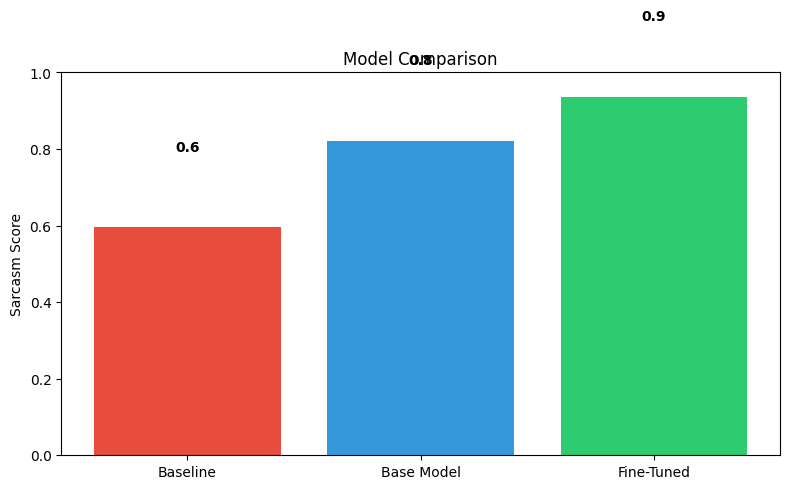

In [38]:
# Visualize
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Baseline', 'Base Model', 'Fine-Tuned']
avgs = [np.mean(baseline_scores), np.mean(base_scores), np.mean(ft_scores)]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax.bar(models, avgs, color=colors)
ax.set_ylabel('Sarcasm Score')
ax.set_title('Model Comparison')
ax.set_ylim(0, 1)

for bar, v in zip(bars, avgs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Cleanup

In [39]:
# Clean up local files
for f in [training_file_path, validation_file_path, base_eval_file, ft_eval_file]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")

print("\n✓ Cleanup complete")

Deleted: training_sarcasm_4aa88349.jsonl
Deleted: validation_sarcasm_4aa88349.jsonl
Deleted: base_eval_4aa88349.jsonl
Deleted: ft_eval_4aa88349.jsonl

✓ Cleanup complete
